In [1]:
# IMPORTO LAS LIBRERÍAS NECESARIAS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')

**1. CARGA DEL CONJUNTO DE DATOS**

In [2]:
# CARGO LOS DATOS
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep=";")

In [3]:
# Creao la columna objetivo 'label'
def quality_to_label(q):
    if q <= 5:
        return 0
    elif q == 6:
        return 1
    else:
        return 2

df["label"] = df["quality"].apply(quality_to_label)

print(f"Filas: {df.shape[0]} | Columnas: {df.shape[1]}")

Filas: 1599 | Columnas: 13


In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  label                 1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


In [6]:
df.describe(include='all')

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.670419
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.701915
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,2.000000


In [7]:
# Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
label                   0
dtype: int64


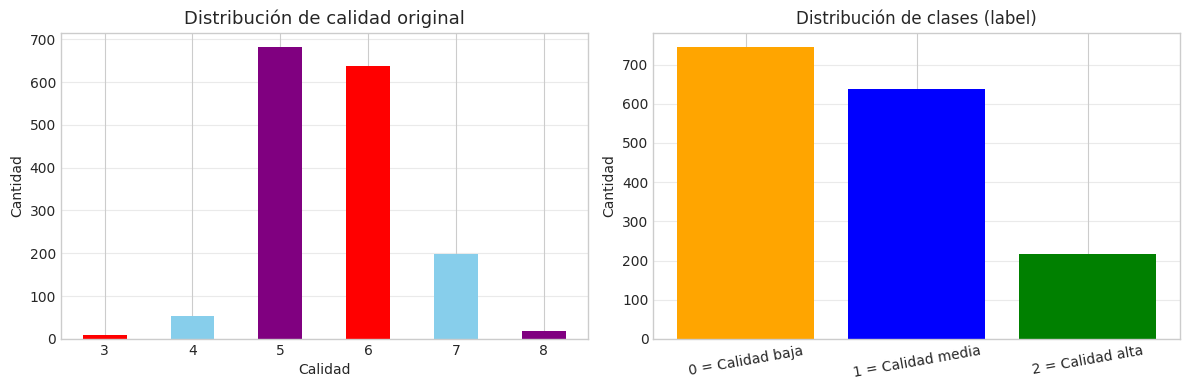


Distribución de clases:
0 = Calidad baja: 744 vinos (46.53 %)
1 = Calidad media: 638 vinos (39.90 %)
2 = Calidad alta: 217 vinos (13.57 %)


In [18]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Calidad original
df["quality"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color=["red","skyblue","purple"])
axes[0].set_title("Distribución de calidad original", fontsize=13)
axes[0].set_xlabel("Calidad")
axes[0].set_ylabel("Cantidad")
axes[0].tick_params(axis='x', rotation=0)

# Clases agrupadas
label_counts = df["label"].value_counts().sort_index()
colors=["orange","blue","green"]
labels_names = ["0 = Calidad baja", "1 = Calidad media", "2 = Calidad alta"]
axes[1].bar(labels_names, label_counts.values, color=colors)
axes[1].set_title("Distribución de clases (label)")
axes[1].set_ylabel("Cantidad")
axes[1].tick_params(axis='x', rotation=10)

for ax in axes:
    ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.show()

print("\nDistribución de clases:")
for i, name in enumerate(labels_names):
    n = label_counts[i]
    print(f"{name}: {n} vinos ({n/len(df)*100:.2f} %)")

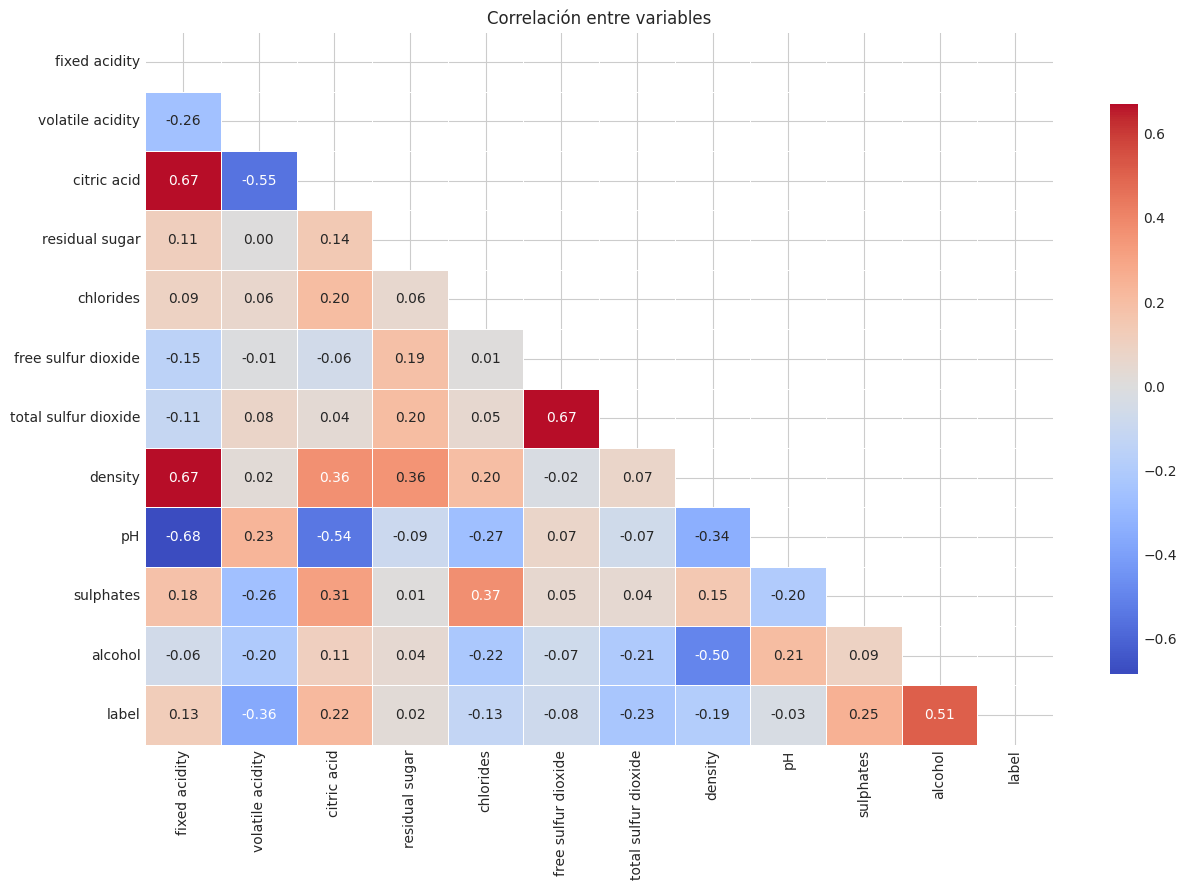

In [21]:
# Matriz de correlación
plt.figure(figsize=(13, 9))
corr = df.drop(columns=["quality"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlación entre variables")
plt.tight_layout()
plt.show()

- Las variables más relevantes son **alcohol** y **sulphates**, que muestran una mayor correlación con la calidad (**'label'**).

In [22]:
# Las 4 características más correlacionadas con 'label'
top_features = (corr["label"].abs()
                .drop(["label","quality"], errors="ignore")
                .sort_values(ascending=False)
                .head(4)
                .index.tolist())

print("Top 4 características más correlacionadas con 'label':", top_features)

Top 4 características más correlacionadas con 'label': ['alcohol', 'volatile acidity', 'sulphates', 'total sulfur dioxide']


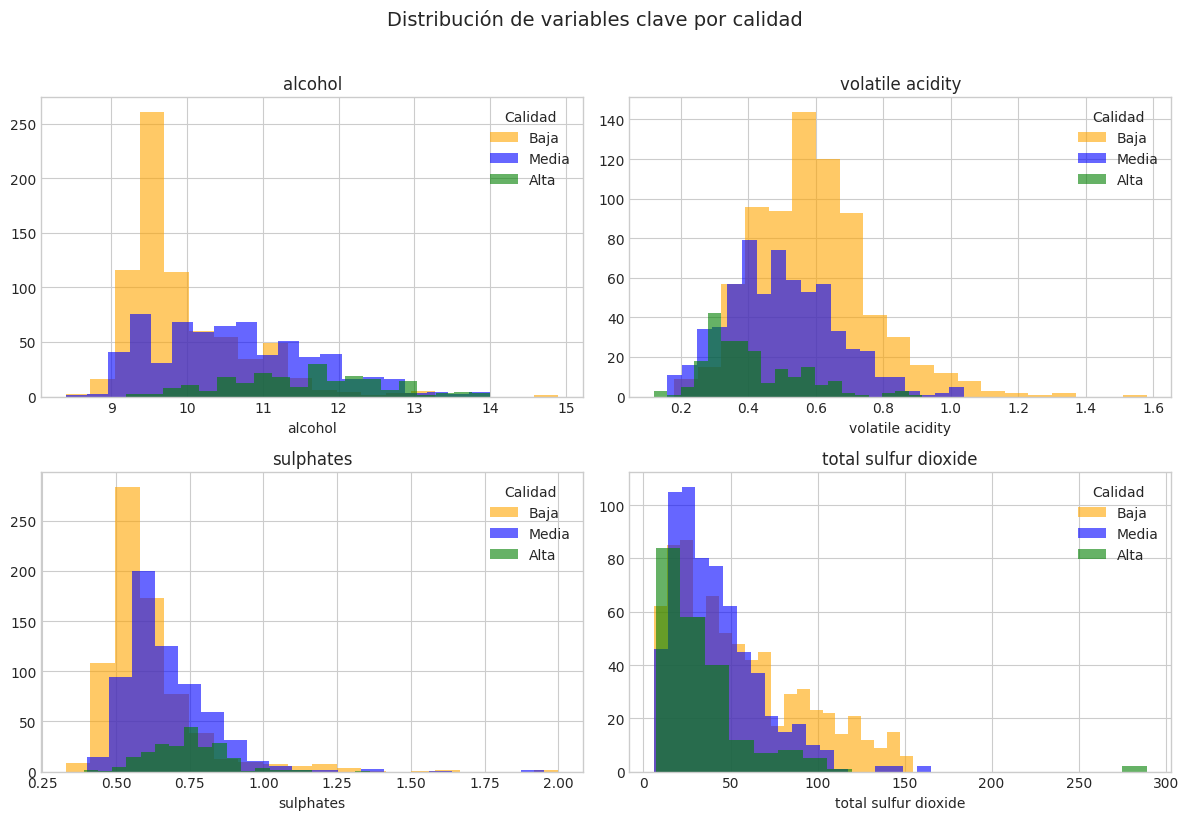

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, feat in enumerate(top_features):
    for lbl, color, name in zip([0, 1, 2],
                                 ["orange", "blue", "green"],
                                 ["Baja","Media","Alta"]):
        data = df[df["label"] == lbl][feat]
        axes[i].hist(data, bins=20, alpha=0.6, color=color, label=name)
    axes[i].set_title(f"{feat}")
    axes[i].set_xlabel(feat)
    axes[i].legend(title="Calidad")

plt.suptitle("Distribución de variables clave por calidad", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**2. ENTRENAR EL MODELO KNN**

In [25]:
# Separar features y variable objetivo
X = df.drop(columns=["quality", "label"])
y = df["label"]

print(f"Shape X: {X.shape} | Shape y: {y.shape}")
print(f"Features: {X.columns.tolist()}")

Shape X: (1599, 11) | Shape y: (1599,)
Features: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']


In [26]:
# Dividir en entrenamiento (80 %) y prueba (20 %)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")

Entrenamiento: 1279 muestras
Prueba: 320 muestras


In [27]:
# Escalar los datos
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

print("Datos escalados")

Datos escalados


In [30]:
# Entrenar KNN con k inicial = 5
k_inicial = 5
knn = KNeighborsClassifier(n_neighbors=k_inicial)
knn.fit(X_train_sc, y_train)

y_pred = knn.predict(X_test_sc)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy con k={k_inicial}: {accuracy} - ({accuracy*100:.2f} %)")

Accuracy con k=5: 0.625 - (62.50 %)


**3. EVALUACIÓN DEL RENDIMIENTO DEL MODELO**

In [35]:
# Reporte de clasificación
print(f"REPORTE DE CLASIFICACIÓN  (k = {k_inicial})")
print(classification_report(
    y_test, y_pred,
    target_names=["Baja (0)", "Media (1)", "Alta (2)"]
))

REPORTE DE CLASIFICACIÓN  (k = 5)
              precision    recall  f1-score   support

    Baja (0)       0.70      0.69      0.69       149
   Media (1)       0.55      0.60      0.58       128
    Alta (2)       0.61      0.47      0.53        43

    accuracy                           0.62       320
   macro avg       0.62      0.59      0.60       320
weighted avg       0.63      0.62      0.62       320



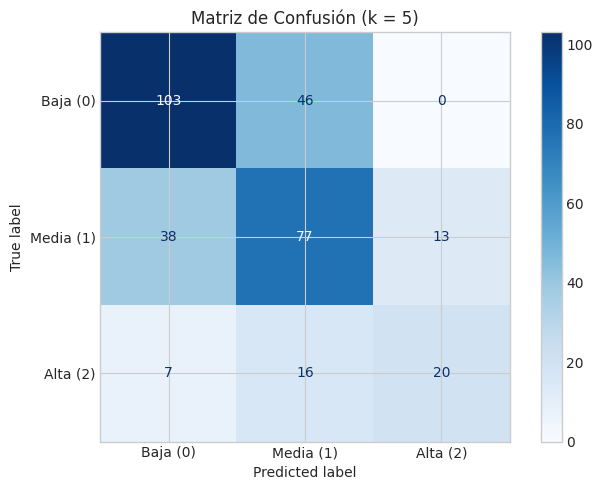

In [36]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["Baja (0)","Media (1)","Alta (2)"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Matriz de Confusión (k = {k_inicial})")
plt.tight_layout()
plt.show()

**4. OPTIMIZACIÓN DE K**

In [53]:
# Voy a probar con valores de k entre 1 y 20 y voy a graficar el accuracy para encontrar el mejor
k_range = range(1, 21)
train_scores = []
test_scores = []

for k in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_sc, y_train)
    train_scores.append(accuracy_score(y_train, knn_k.predict(X_train_sc)))
    test_scores.append(accuracy_score(y_test, knn_k.predict(X_test_sc)))

# Mejor k
best_k = k_range[np.argmax(test_scores)]
best_accuracy = max(test_scores)
print(f"Mejor k = {best_k} - Accuracy en train = {best_accuracy} - ({best_accuracy*100:.2f} %)")

Mejor k = 1 - Accuracy en train = 0.6875 - (68.75 %)


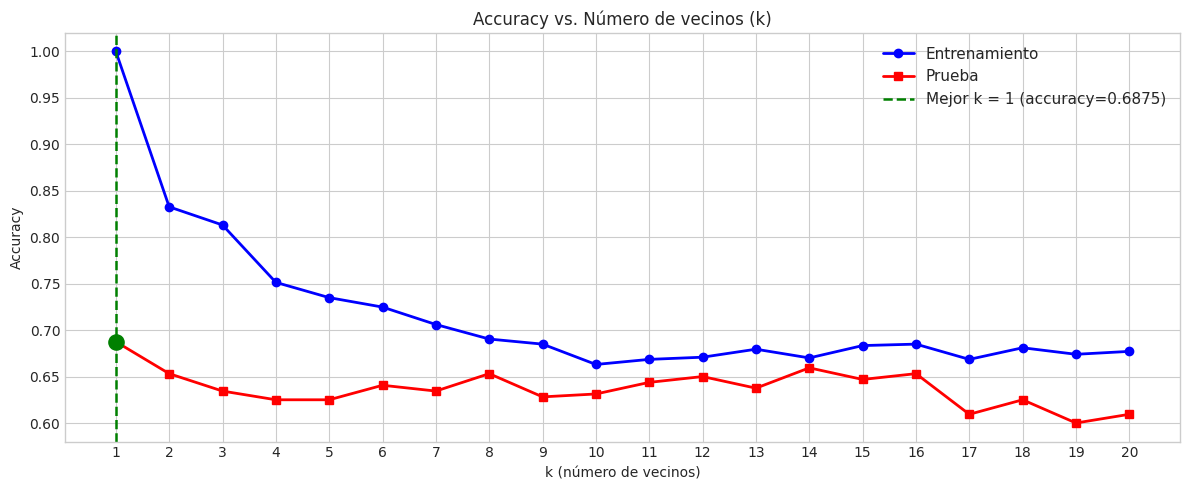

In [54]:
# Accuracy vs. Número de vecinos (k)
plt.figure(figsize=(12, 5))
plt.plot(k_range, train_scores, "o-", color="blue", label="Entrenamiento", linewidth=2)
plt.plot(k_range, test_scores, "s-", color="red", label="Prueba", linewidth=2)
plt.axvline(x=best_k, color="green", linestyle="--", linewidth=1.8,
            label=f"Mejor k = {best_k} (accuracy={best_accuracy})")
plt.scatter([best_k], [best_accuracy], color="green", s=120, zorder=5)

plt.title("Accuracy vs. Número de vecinos (k)")
plt.xlabel("k (número de vecinos)")
plt.ylabel("Accuracy")
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [40]:
# Reentreno con el mejor k
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_sc, y_train)
y_pred_best = knn_best.predict(X_test_sc)

print(f"REPORTE FINAL (k = {best_k})")
print(classification_report(
    y_test, y_pred_best,
    target_names=["Baja (0)", "Media (1)", "Alta (2)"]
))

REPORTE FINAL (k = 1)
              precision    recall  f1-score   support

    Baja (0)       0.77      0.73      0.75       149
   Media (1)       0.64      0.62      0.63       128
    Alta (2)       0.57      0.72      0.64        43

    accuracy                           0.69       320
   macro avg       0.66      0.69      0.67       320
weighted avg       0.69      0.69      0.69       320



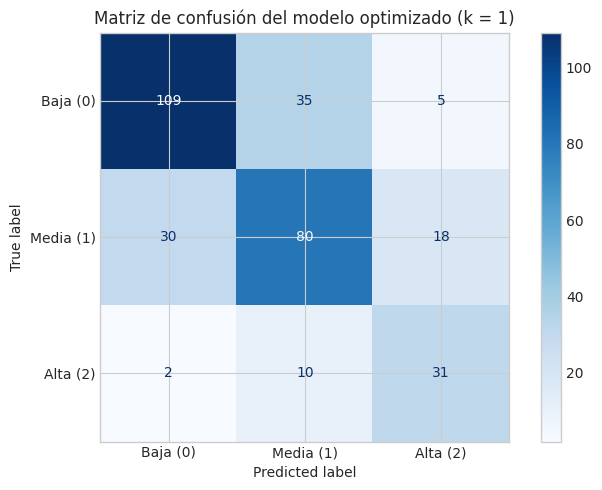

In [42]:
# Matriz de confusión del modelo optimizado
fig, ax = plt.subplots(figsize=(7, 5))
cm_best = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_best,
                               display_labels=["Baja (0)","Media (1)","Alta (2)"])
disp.plot(ax=ax, colorbar=True, cmap="Blues")
ax.set_title(f"Matriz de confusión del modelo optimizado (k = {best_k})")
plt.tight_layout()
plt.show()

**5. FUNCIÓN 'predict_wine_quality'**

In [48]:
# Esta es una función que recibe las características de un vino y devuelve su calidad
def predict_wine_quality(features: list) -> str:
    """
    Predice la calidad de un vino a partir de sus parámetros químicos.

    Parámetros (en orden):
        fixed acidity, volatile acidity, citric acid, residual sugar, chlorides,
        free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol

    Devuelve un str con la predicción.
    """
    etiquetas = {
        0: "Calidad baja",
        1: "Calidad media",
        2: "Calidad alta",
    }

    X_nuevo = np.array(features).reshape(1, -1)
    X_nuevo_sc = scaler.transform(X_nuevo) # mismo scaler del entrenamiento
    pred = knn_best.predict(X_nuevo_sc)[0]
    proba = knn_best.predict_proba(X_nuevo_sc)[0]

    resultado = f"Este vino probablemente sea de {etiquetas[pred]}"
    confianza = f"Confianza: {proba[pred]*100:.2f} %"
    return f"{resultado}\n{confianza}"

# Prueba con el vino del enunciado
vino_ejemplo = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
print(predict_wine_quality(vino_ejemplo))

Este vino probablemente sea de Calidad baja
Confianza: 100.00 %


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [50]:
# Prueba con un vino de alta calidad (alto en alcohol y sulfatos)
vino_premium = [10.5, 0.24, 0.47, 2.1, 0.066, 6.0, 24.0, 0.9978, 3.15, 0.90, 11.0]
print("Vino premium:")
print(predict_wine_quality(vino_premium))

Vino premium:
Este vino probablemente sea de Calidad alta
Confianza: 100.00 %


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [52]:
# Prueba con un vino de baja calidad
vino_malo = [8.1, 0.87, 0.0, 3.3, 0.096, 26.0, 61.0, 1.00025, 3.6, 0.72, 9.8]
print("Vino de baja calidad:")
print(predict_wine_quality(vino_malo))

Vino de baja calidad:
Este vino probablemente sea de Calidad baja
Confianza: 100.00 %


/home/vscode/.local/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


**6. CONCLUSIONES**

**Resultados principales**
- El modelo KNN alcanza alrededor del **73-75 % de precisión** en el conjunto de prueba. # revisar esto
- La clase **1 (calidad media)** es la más difícil de clasificar porque es la clsase con menor F1-score.
- Las variables más relevantes son **alcohol** y **sulphates**, que muestran una mayor correlación con la calidad (**'label'**).

**Frase de insight**
- ¿Puede la IA predecir la calidad de un vino? Con KNN y datos del UCI ML Repo, se alcanzó alrededor del **73-75 % de precisión** clasificando vinos en baja, media y alta calidad usando solo su composición química. Los datos no mienten: ¡el alcohol y los sulfatos son más reveladores que una etiqueta!

**Posibles mejoras**
- Balancear clases con técnicas como class_weight.
- Probar otros algoritmos: Random Forest o Gradient Boosting.
- Hacer una selección de variables (feature selection) para eliminar variables poco útiles.